<a href="https://colab.research.google.com/github/Zine-Elabidine/Positional-Encodings-Overview/blob/main/Positional_Encodings_Overview.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> "You shall know a word by the company it keeps"  
> — *John Rupert Firth*

In this notebook we go over positional encodings, their purpose in transformer architecture models, how they evolved over time








### 🔍 Why Do We Need Positional Encodings?
Transformers don't have recurrence or convolution, so they treat the input sequence as a set of tokens — no inherent sense of order. But language (and most sequential data) has order.


Positional encodings inject a notion of *order* into the input embeddings.

###Requirements for Positional Encodings
In a transformer architecture, we need positional encodings that have the following properties:

* **Uniqueness:** Each position must have a distinct representation so the model can differentiate positions.

* **Bounded values:** Values shouldn't explode for long sequences or disrupt the learned token embeddings.

* **Generalization:** The encoding scheme should work for sequences longer than those seen during training.

* **Information density:** Position information should be effectively captured across the entire embedding space.

* **Relative position awareness**: The model should understand relative positions (e.g., "3 words apart").

# Absolute Positional Encoding (Vaswani et al.,2017)

In the vanilla transformer architecture (Vaswani et al., 2017), positional encodings are defined by the following equations:

For each position $pos$ and dimension $i$:

$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

Where:
- $pos$ is the position in the sequence (starting from 0)
- $i$ is the dimension index (for the even dimensions)
- $d_{model}$ is the dimensionality of the embedding vectors



For a 512-dimensional embedding:

* Positions are encoded as 512-dimensional vectors.

* Each dimension represents a sinusoid with a specific frequency.

* Even-numbered dimensions use sin(position × frequency)

* Odd-numbered dimensions use cos(position × frequency)

These positional encodings are added to the input embeddings before being fed into the encoder and decoder stacks:

$$\text{Input to First Layer} = \text{WordEmbedding} + \text{PositionalEncoding}$$

The wavelengths form a geometric progression from $2\pi$ to $10000 \cdot 2\pi$, providing the model with information about relative positions.

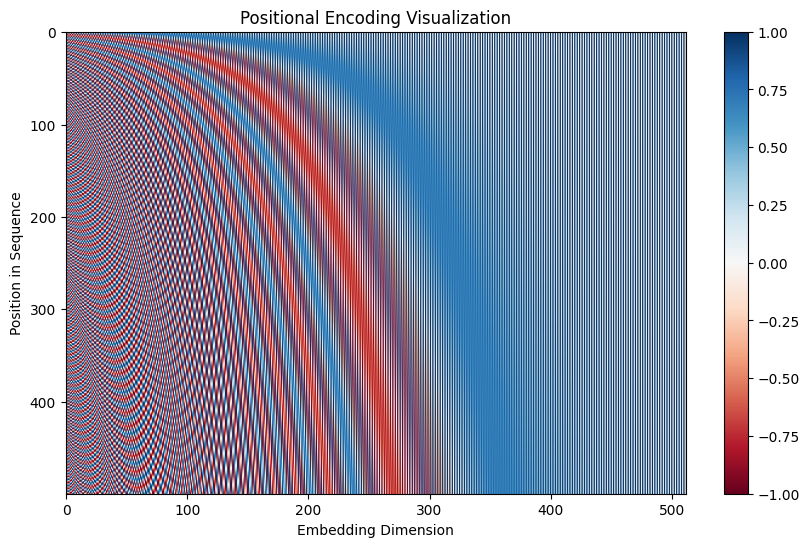

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def get_positional_encoding(seq_len, d_model, base=10000):
    position = np.arange(seq_len)[:, np.newaxis]
    div_term = np.exp(np.arange(0, d_model, 2) * (-np.log(base) / d_model))
    pe = np.zeros((seq_len, d_model))
    pe[:, 0::2] = np.sin(position * div_term)
    pe[:, 1::2] = np.cos(position * div_term)
    return pe

# Example usage
seq_length = 500 # sequence length
d_model = 512      # embedding dimension

# Generate positional encodings
pos_encoding = get_positional_encoding(seq_length, d_model)

# Visualization example
plt.figure(figsize=(10, 6))
plt.imshow(pos_encoding, cmap='RdBu', aspect='auto')
plt.xlabel('Embedding Dimension')
plt.ylabel('Position in Sequence')
plt.colorbar()
plt.title('Positional Encoding Visualization')
plt.show()

as we can see in the figure, each horizontal line corresponds to a vector word embedding, and due to the nature of sine and cosine function, we get two consequences :

As $i$ (the dimension index) increases:

* The denominator becomes larger, which means the value inside $sin$ or $cos$ becomes smaller.

* This causes the sine/cosine to oscillate faster with increasing p.

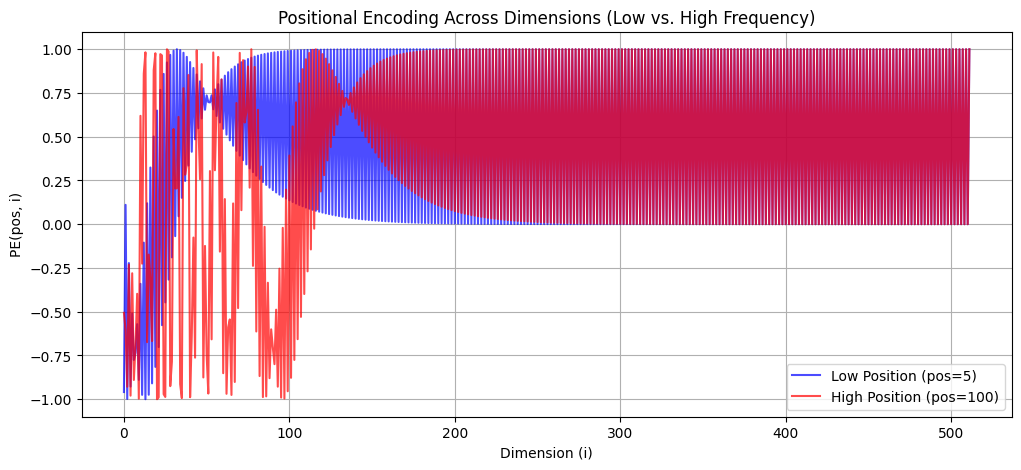

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def get_positional_encoding(pos, d_model=512, base=10000):
    i = np.arange(d_model)
    angle = pos / (base ** (2 * i / d_model))
    pe = np.zeros(d_model)
    pe[0::2] = np.sin(angle[0::2])  # Even indices: sine
    pe[1::2] = np.cos(angle[1::2])  # Odd indices: cosine
    return pe

d_model = 512
pos_low = 5    # Low position
pos_high = 100 # High position

# Get PE for both positions across all dimensions
pe_low = get_positional_encoding(pos_low, d_model)
pe_high = get_positional_encoding(pos_high, d_model)

# Plot
plt.figure(figsize=(12, 5))
plt.plot(pe_low, label=f'Low Position (pos={pos_low})', color='blue', alpha=0.7)
plt.plot(pe_high, label=f'High Position (pos={pos_high})', color='red', alpha=0.7)
plt.xlabel('Dimension (i)')
plt.ylabel('PE(pos, i)')
plt.title('Positional Encoding Across Dimensions (Low vs. High Frequency)')
plt.legend()
plt.grid()
plt.show()

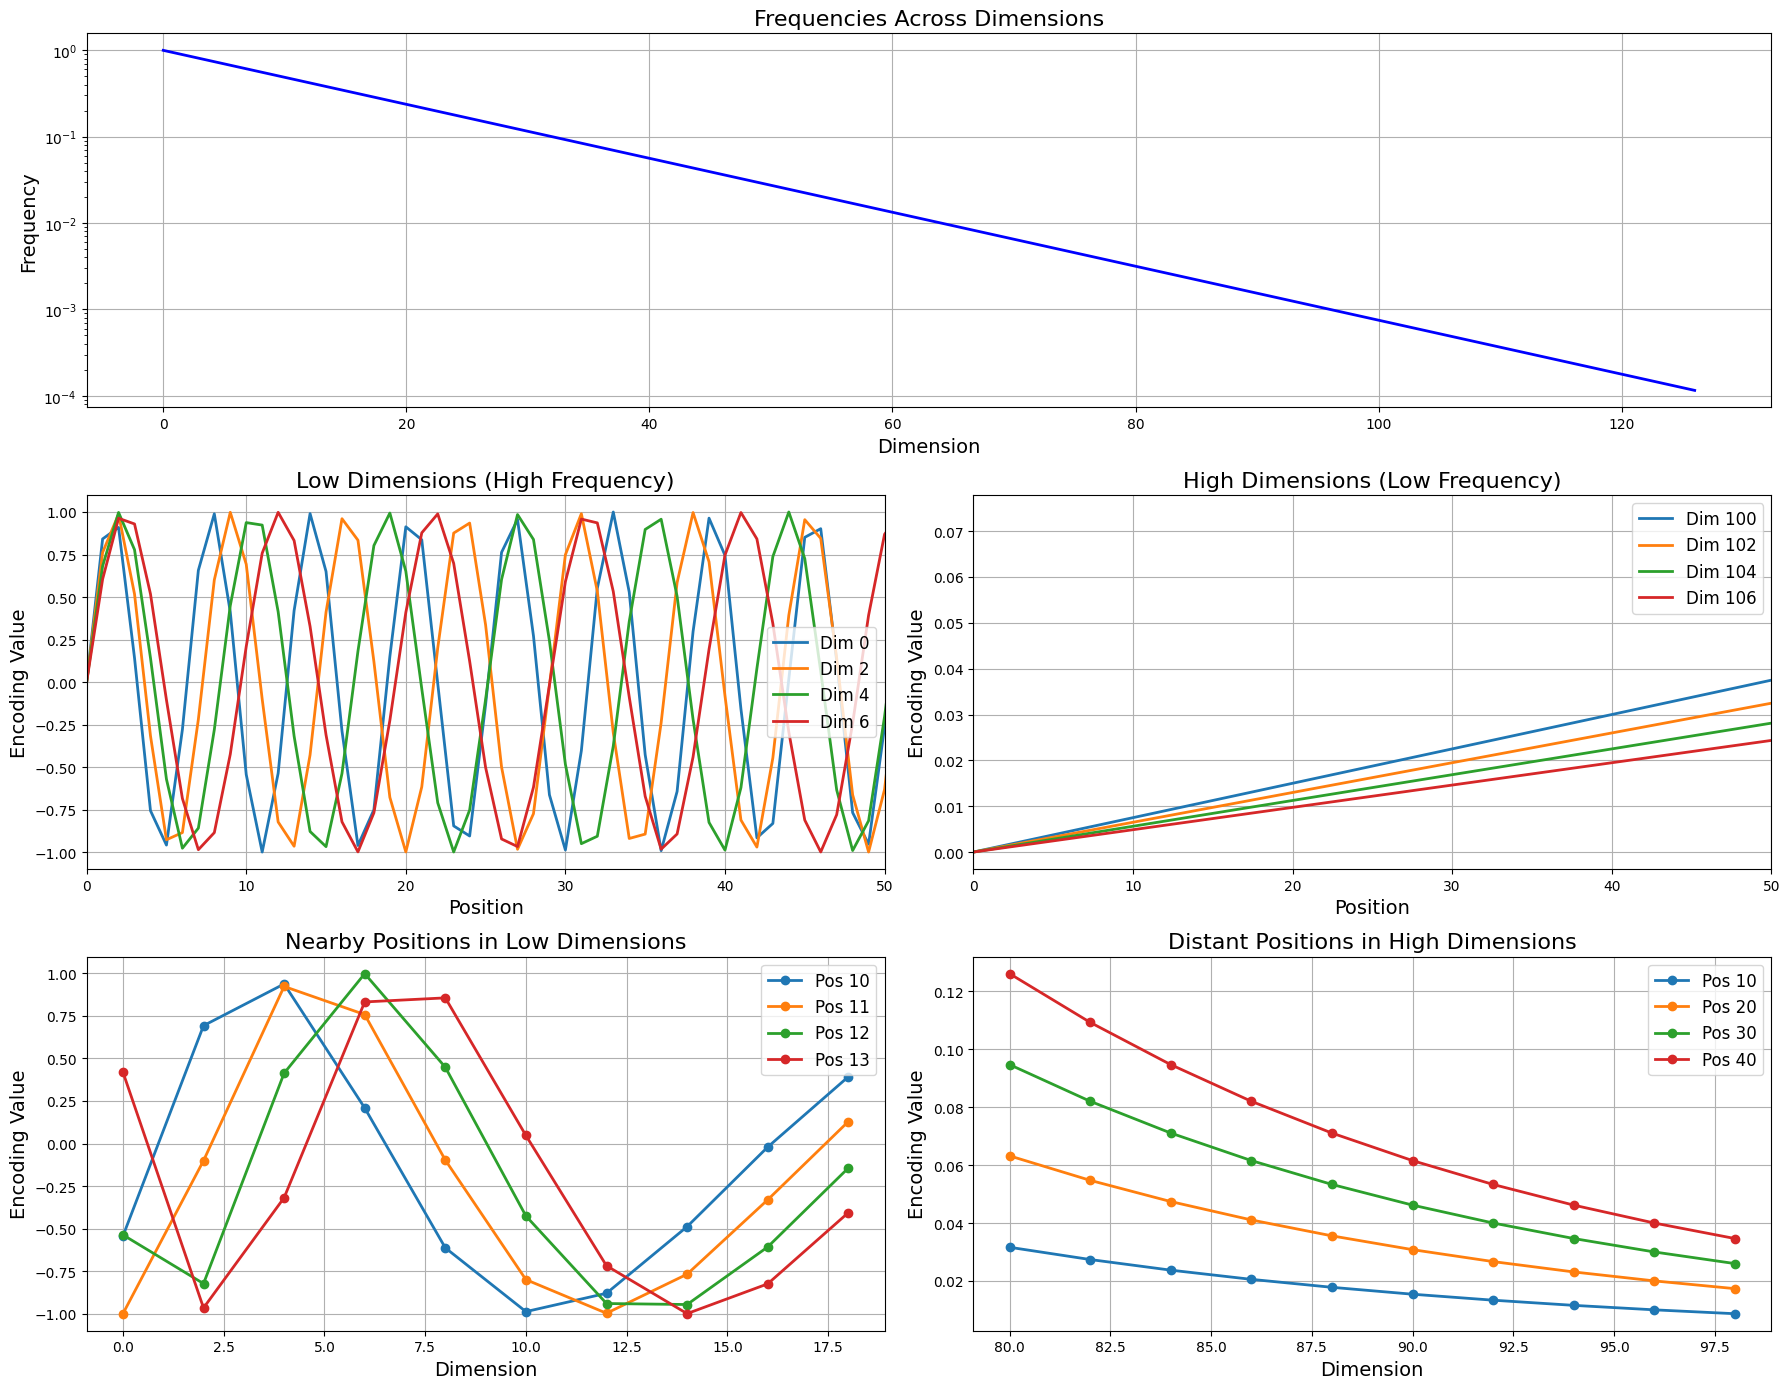

Position comparison (cosine similarity):
Positions | Low Dims | High Dims | Full Vector
--------------------------------------------------
5 vs  6 | 0.8206  | 1.0000   | 0.9702
5 vs 10 | -0.4186  | 1.0000   | 0.7373
5 vs 20 | 0.0579  | 1.0000   | 0.6326
5 vs 50 | 0.0660  | 0.9999   | 0.5168


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Parameters
d_model = 128
seq_length = 100

# Calculate positional encodings
def get_positional_encoding(seq_len, d_model):
    position_enc = np.zeros((seq_len, d_model))
    for pos in range(seq_len):
        for i in range(0, d_model, 2):
            div_term = 10000 ** (i / d_model)
            position_enc[pos, i] = np.sin(pos / div_term)
            if i + 1 < d_model:
                position_enc[pos, i + 1] = np.cos(pos / div_term)
    return position_enc

pos_encodings = get_positional_encoding(seq_length, d_model)

# Create a figure with multiple subplots
fig = plt.figure(figsize=(18, 14))
gs = GridSpec(3, 2, figure=fig)

# 1. Plot frequencies across dimensions
ax1 = fig.add_subplot(gs[0, :])
wavelengths = [10000 ** (i / d_model) for i in range(0, d_model, 2)]
frequencies = [1/w for w in wavelengths]

ax1.plot(range(0, d_model, 2), frequencies, 'b-', linewidth=2)
ax1.set_title('Frequencies Across Dimensions', fontsize=16)
ax1.set_xlabel('Dimension', fontsize=14)
ax1.set_ylabel('Frequency', fontsize=14)
ax1.set_yscale('log')
ax1.grid(True)

# 2. Plot low dimensions (high frequency) across positions
ax2 = fig.add_subplot(gs[1, 0])
# Select a few low dimensions
low_dims = [0, 2, 4, 6]
for dim in low_dims:
    ax2.plot(range(seq_length), pos_encodings[:, dim],
             label=f'Dim {dim}', linewidth=2)
ax2.set_title('Low Dimensions (High Frequency)', fontsize=16)
ax2.set_xlabel('Position', fontsize=14)
ax2.set_ylabel('Encoding Value', fontsize=14)
ax2.legend(fontsize=12)
ax2.grid(True)
ax2.set_xlim(0, 50)

# 3. Plot high dimensions (low frequency) across positions
ax3 = fig.add_subplot(gs[1, 1])
# Select a few high dimensions
high_dims = [100, 102, 104, 106]
for dim in high_dims:
    ax3.plot(range(seq_length), pos_encodings[:, dim],
             label=f'Dim {dim}', linewidth=2)
ax3.set_title('High Dimensions (Low Frequency)', fontsize=16)
ax3.set_xlabel('Position', fontsize=14)
ax3.set_ylabel('Encoding Value', fontsize=14)
ax3.legend(fontsize=12)
ax3.grid(True)
ax3.set_xlim(0, 50)

# 4. Compare nearby positions in different dimensions
ax4 = fig.add_subplot(gs[2, 0])
nearby_pos = [10, 11, 12, 13]
for pos in nearby_pos:
    ax4.plot(range(0, 20, 2), [pos_encodings[pos, i] for i in range(0, 20, 2)],
             label=f'Pos {pos}', linewidth=2, marker='o')
ax4.set_title('Nearby Positions in Low Dimensions', fontsize=16)
ax4.set_xlabel('Dimension', fontsize=14)
ax4.set_ylabel('Encoding Value', fontsize=14)
ax4.legend(fontsize=12)
ax4.grid(True)

# 5. Compare distant positions in different dimensions
ax5 = fig.add_subplot(gs[2, 1])
distant_pos = [10, 20, 30, 40]
for pos in distant_pos:
    ax5.plot(range(80, 100, 2), [pos_encodings[pos, i] for i in range(80, 100, 2)],
             label=f'Pos {pos}', linewidth=2, marker='o')
ax5.set_title('Distant Positions in High Dimensions', fontsize=16)
ax5.set_xlabel('Dimension', fontsize=14)
ax5.set_ylabel('Encoding Value', fontsize=14)
ax5.legend(fontsize=12)
ax5.grid(True)

plt.tight_layout()
plt.show()

# Demonstrate position discrimination
# Calculate the cosine similarity between nearby positions
from sklearn.metrics.pairwise import cosine_similarity

def compare_positions(pos1, pos2):
    """Compare how positions differ in low vs high dimensions"""
    # Get encodings for the positions
    enc_pos1 = pos_encodings[pos1]
    enc_pos2 = pos_encodings[pos2]

    # Compare low dimensions (first 20)
    low_dims_sim = cosine_similarity([enc_pos1[:20]], [enc_pos2[:20]])[0][0]

    # Compare high dimensions (last 20)
    high_dims_sim = cosine_similarity([enc_pos1[-20:]], [enc_pos2[-20:]])[0][0]

    # Compare all dimensions
    full_sim = cosine_similarity([enc_pos1], [enc_pos2])[0][0]

    return low_dims_sim, high_dims_sim, full_sim

# Compare nearby positions
nearby_comparison = [(5, 6), (5, 10), (5, 20), (5, 50)]

print("Position comparison (cosine similarity):")
print("Positions | Low Dims | High Dims | Full Vector")
print("-" * 50)
for pos1, pos2 in nearby_comparison:
    low, high, full = compare_positions(pos1, pos2)
    print(f"{pos1} vs {pos2:2d} | {low:.4f}  | {high:.4f}   | {full:.4f}")

### How Different Dimensions Work Together
####Low Dimensions (High Frequency)

Low-numbered dimensions (close to 0) use high-frequency waves that complete many cycles even within short sequences:

* **Advantages:** Excellent at distinguishing nearby positions with precision

* **Example:** Dimensions 0-20 can easily tell position 10 from position 11

* **Pattern:** These dimensions show rapid oscillations, changing value significantly even between adjacent positions

* **Limitation:** The pattern repeats after short intervals, so they can't distinguish distant positions by themselves





####High Dimensions (Low Frequency)
High-numbered dimensions (close to d_model) use low-frequency waves that change very slowly:

* **Advantages:** Good at preserving information about broader position ranges

* **Example:** Dimensions 100-120 have similar values for positions 10 and 11, but different values for positions 10 and 50

* **Pattern:** These dimensions show gradual changes across positions, creating a smooth gradient

* **Limitation:** Low precision for neighboring positions

## Why Sine and Cosine ? why not just Sine

Short Answer : ***Trigonometric Properties***

###Long Answer
The relationship between positions should be mathematically simple. If we know the encoding for position
$p$ , it should be straightforward to compute the encoding for position
$p+k$, making it easier for the model to learn positional patterns.The trigonometric properties of sine and cosine functions makes this easy

Mathematically, we want:   
$$PE(pos+k)=M(k)⋅PE(pos)$$







#### Positional Encoding Formula

For a given dimension $i$, the encoding at position $pos$ is:

$$PE(pos,2i)=\sin(pos \cdot \theta_i)$$
$$PE(pos,2i+1)=\cos(pos \cdot \theta_i)$$

where $\theta_i=10000^{-2i/d}$.

#### Trigonometric Identity for Linear Offset

Consider an offset $k$. For any $pos$, we can express $PE(pos+k)$ using angle addition formulas:

$$\sin(pos \cdot \theta_i + k \cdot \theta_i) = \sin(pos \cdot \theta_i)\cos(k \cdot \theta_i) + \cos(pos \cdot \theta_i)\sin(k \cdot \theta_i)$$

$$\cos(pos \cdot \theta_i + k \cdot \theta_i) = \cos(pos \cdot \theta_i)\cos(k \cdot \theta_i) - \sin(pos \cdot \theta_i)\sin(k \cdot \theta_i)$$

#### Matrix Form (Linear Transformation)

Rewriting the above as a matrix-vector multiplication:

$$\begin{bmatrix} PE(pos+k,2i) \\ PE(pos+k,2i+1) \end{bmatrix} = \begin{bmatrix} \cos(k \cdot \theta_i) & \sin(k \cdot \theta_i) \\ -\sin(k \cdot \theta_i) & \cos(k \cdot \theta_i) \end{bmatrix} \cdot \begin{bmatrix} PE(pos,2i) \\ PE(pos,2i+1) \end{bmatrix}$$

This is a **rotation matrix**! It depends only on $k$ and $\theta_i$, not on $pos$.

#### Why This Matters

* The model can **derive relative positions** (e.g., "token at $pos+k$") by applying this linear transformation to the encoding of $pos$.
* This enables **generalization to longer sequences** because the relationship holds for any $pos$ and $k$.

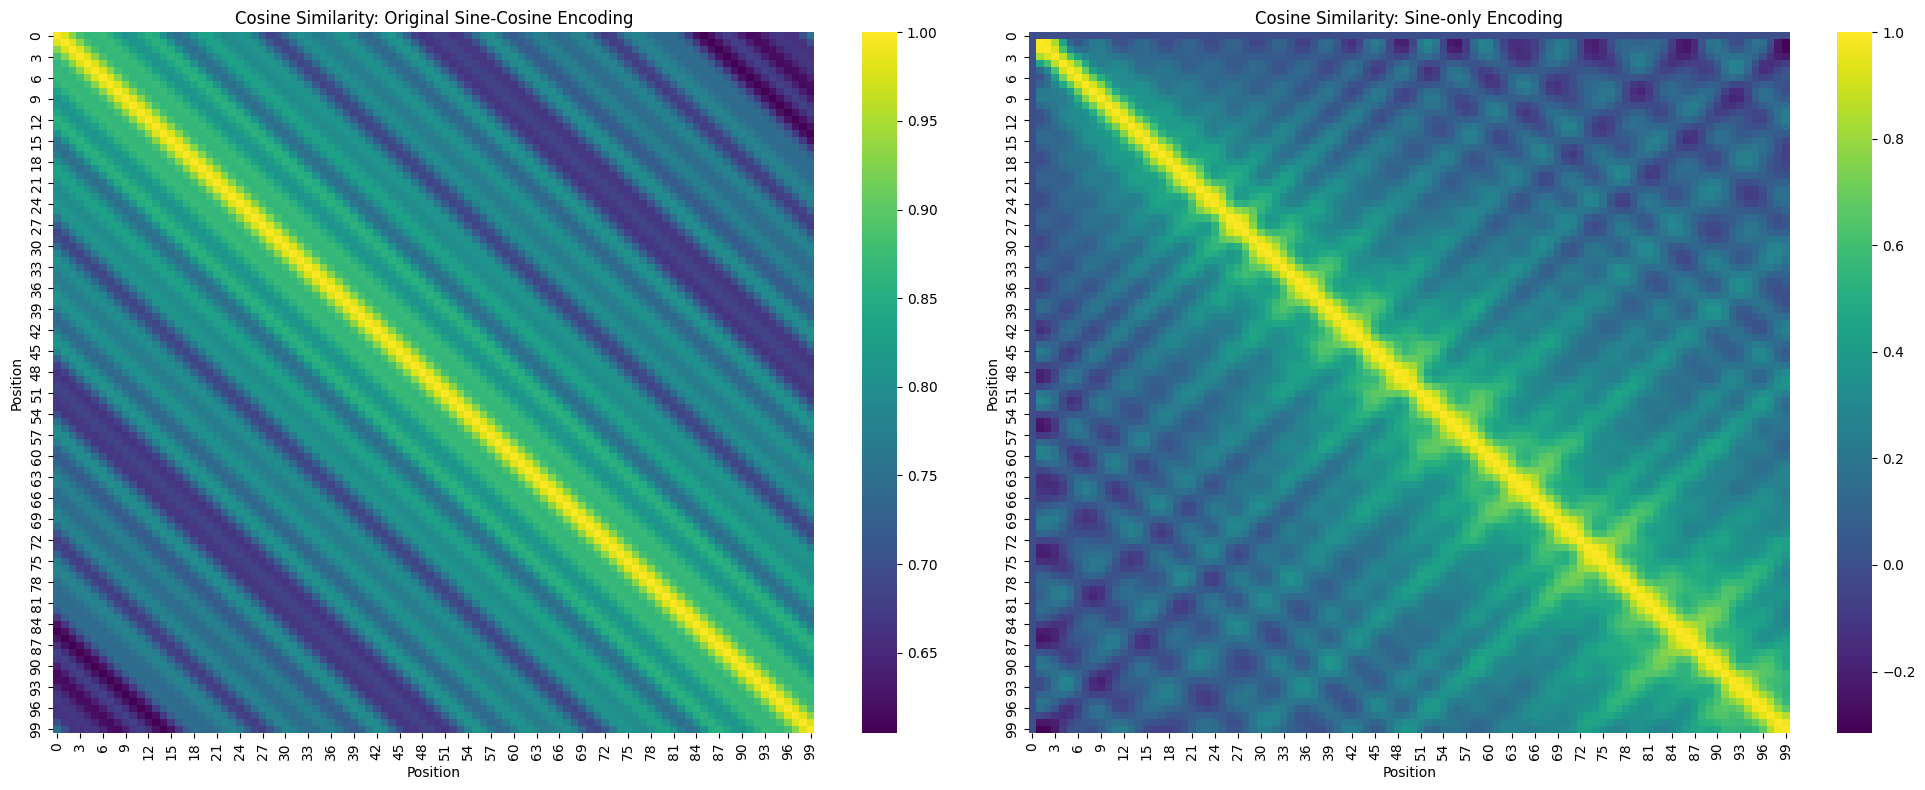

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns

def pe_original(positions, d_model=64):
    """Original transformer positional encoding with sine and cosine"""
    encodings = np.zeros((len(positions), d_model))
    for pos in range(len(positions)):
        for i in range(0, d_model, 2):
            factor = np.power(10000, 2 * i / d_model)
            encodings[pos, i] = np.sin(positions[pos] / factor)
            if i + 1 < d_model:
                encodings[pos, i + 1] = np.cos(positions[pos] / factor)
    return encodings

def pe_sine_only(positions, d_model=64):
    """Alternative: Using only sine functions with different frequencies"""
    encodings = np.zeros((len(positions), d_model))
    for pos in range(len(positions)):
        for i in range(d_model):
            factor = np.power(10000, i / d_model)
            encodings[pos, i] = np.sin(positions[pos] / factor)
    return encodings

# Create positions up to 100
positions = np.arange(100)
d_model = 64

# Calculate both types of encodings
original_encodings = pe_original(positions, d_model)
sine_only_encodings = pe_sine_only(positions, d_model)

# 1. Compare similarity matrices
plt.figure(figsize=(20, 8))

# Original encodings similarity
plt.subplot(1, 2, 1)
original_sim = cosine_similarity(original_encodings)
sns.heatmap(original_sim, cmap='viridis')
plt.title('Cosine Similarity: Original Sine-Cosine Encoding')
plt.xlabel('Position')
plt.ylabel('Position')

# Sine-only encodings similarity
plt.subplot(1, 2, 2)
sine_only_sim = cosine_similarity(sine_only_encodings)
sns.heatmap(sine_only_sim, cmap='viridis')
plt.title('Cosine Similarity: Sine-only Encoding')
plt.xlabel('Position')
plt.ylabel('Position')

plt.tight_layout()
plt.savefig('similarity_comparison.png', dpi=300)
plt.show()





In both matrices, the diagonal (yellow line) shows positions compared with themselves, which naturally have perfect similarity (1.0).
The sine-cosine encoding (left) shows a much more structured pattern with clear diagonal bands. These bands represent positions that have similar encodings at regular intervals.
The sine-only encoding (right) has a less structured pattern with more noise and inconsistent similarities between positions.
The sine-cosine encoding maintains clearer distinctions between different positions (more blue areas indicating lower similarity), while the sine-only encoding shows higher similarity values between unrelated positions (more green areas).
Notice the color scales - the sine-cosine encoding similarity values generally range from about 0.65 to 1.0, while the sine-only encoding has a much wider range from -0.2 to 1.0, indicating less stable relationships between positions.

/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


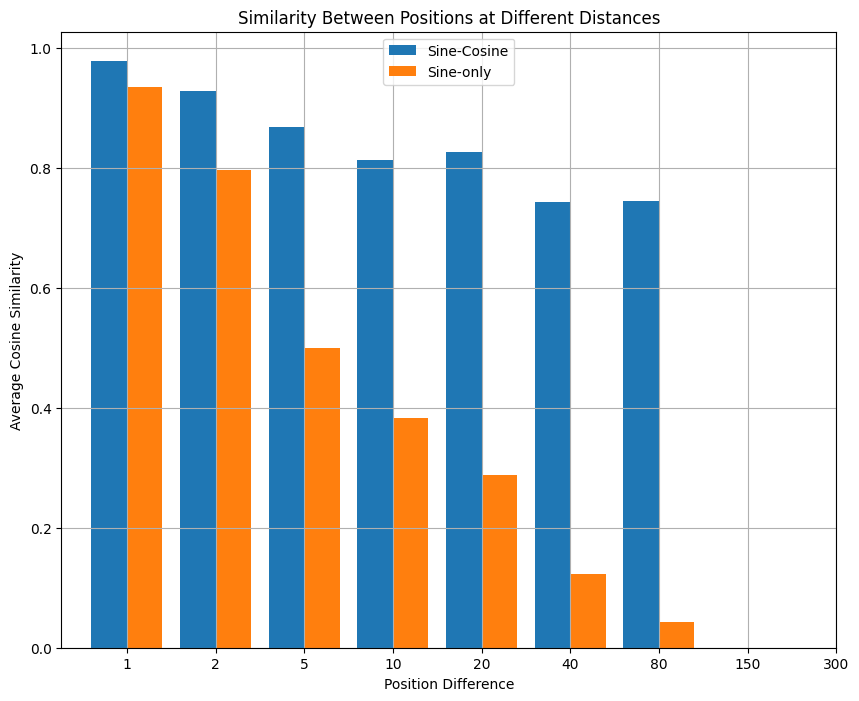

In [ ]:
# 3. Analyze similarity between adjacent positions
pos_diffs = [1, 2, 5, 10, 20, 40,80,150,300]
original_sims = []
sine_only_sims = []

for diff in pos_diffs:
    # Calculate similarity between position i and i+diff
    orig_sim = np.mean([cosine_similarity([original_encodings[i]], [original_encodings[i+diff]])[0][0]
                        for i in range(len(positions)-diff)])
    sine_sim = np.mean([cosine_similarity([sine_only_encodings[i]], [sine_only_encodings[i+diff]])[0][0]
                        for i in range(len(positions)-diff)])

    original_sims.append(orig_sim)
    sine_only_sims.append(sine_sim)

plt.figure(figsize=(10, 8))
plt.bar(np.arange(len(pos_diffs))-0.2, original_sims, width=0.4, label='Sine-Cosine')
plt.bar(np.arange(len(pos_diffs))+0.2, sine_only_sims, width=0.4, label='Sine-only')
plt.xticks(np.arange(len(pos_diffs)), [f'{d}' for d in pos_diffs])
plt.xlabel('Position Difference')
plt.ylabel('Average Cosine Similarity')
plt.title('Similarity Between Positions at Different Distances')
plt.legend()
plt.grid(True)
plt.savefig('position_similarity.png', dpi=300)
plt.show()

For sine-cosine encoding (blue bars), the similarity decreases gradually as the distance between positions increases. Even at a distance of 40 tokens, positions still maintain a relatively high similarity (around 0.75).
For sine-only encoding (orange bars), the similarity drops much more rapidly as distance increases. At a distance of 40 tokens, the similarity is very low (around 0.12).

## How Absolute Positional Encodings Meet Requirements

* **Uniqueness:** The sine-cosine pair at various frequencies creates a unique encoding for each position, equivalent to specifying a unique angle on multiple unit circles of different frequencies.

* **Bounded values:** All values are strictly bounded between -1 and 1 regardless of sequence length, preventing embedding magnitude explosion.

* **Generalization:** The continuous mathematical functions allow seamless extrapolation to positions beyond training data without requiring position-specific training.

* **Information density:** Different dimensions encode position at different frequency scales, distributing positional information efficiently across the embedding dimensions.

* **Relative position awareness:** Positions closer together have more similar encodings with predictable similarity decay, allowing the model to implicitly learn relative positions.